# Worked Example: Feedback-Locked Raw Epochs with Behavior Metadata

## Goal
Epoch around real `feedback_start` and `baseline_start` times (with 1 s buffers), attach reward/RPE metadata, and save **two** raw epoch files for chapter 09 cross-event TFR (buffers cropped on the TFR axis after Morlet, not on voltage).


In [ ]:
import pandas as pd
from pathlib import Path
from LFPAnalysis import build_event_locked_pipeline_config, run_pipeline

beh = pd.read_csv(Path('../../data/sample_beh.csv'))
config = build_event_locked_pipeline_config(
    Path('../../data/sample_ieeg_bp.fif'),
    file_format='mne',
    event_name='feedback_start',
    event_times=beh['feedback_start'].tolist(),
    baseline_mode='none',
    tmin=-0.5,
    tmax=1.5,
    buffer_s=1.0,
    metadata={'reward': beh['reward'].tolist(), 'rpe': beh['rpe'].tolist()},
)
result = run_pipeline(config)
epochs = result.epochs
print(f'{len(epochs)} epochs, reward={epochs.metadata.reward.sum():.0f} win / {(epochs.metadata.reward==0).sum():.0f} loss')
print('Task epoch span (includes 1 s buffer each side):', epochs.times[0], epochs.times[-1])

Opening raw data file /Users/salmanqasim/Documents/GitRepos/LFPAnalysis/data/sample_ieeg_bp.fif...
    Range : 0 ... 394061 =      0.000 ...   788.122 secs
Ready.
Reading 0 ... 394061  =      0.000 ...   788.122 secs...
80 epochs, reward=54 win / 26 loss
   target        channel    mode  baseline_start  baseline_stop  \
0  epochs  racas1-racas2  zscore            -0.5            0.0   
1  epochs  racas2-racas3  zscore            -0.5            0.0   
2  epochs  racas3-racas4  zscore            -0.5            0.0   
3  epochs  racas4-racas5  zscore            -0.5            0.0   
4  epochs  racas5-racas6  zscore            -0.5            0.0   

   baseline_mean  baseline_std  
0      -0.000017      0.000048  
1       0.000019      0.000060  
2      -0.000004      0.000048  
3      -0.000003      0.000032  
4       0.000011      0.000041  


/Users/salmanqasim/Documents/GitRepos/LFPAnalysis/LFPAnalysis/workflow.py:146: RuntimeWarning: This filename (/Users/salmanqasim/Documents/GitRepos/LFPAnalysis/data/sample_ieeg_bp.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  data = mne.io.read_raw_fif(path, preload=config.preload)


## Plot single-trial raw epochs (ACC channel)

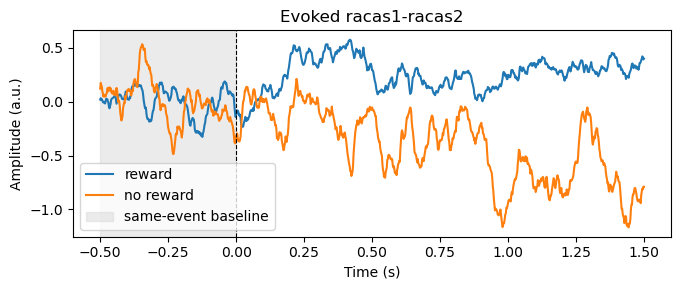

In [2]:
import matplotlib.pyplot as plt

chan = 'racas1-racas2'
reward_trial = epochs[epochs.metadata['reward'] == 1][0].copy().pick([chan])
loss_trial = epochs[epochs.metadata['reward'] == 0][0].copy().pick([chan])
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(reward_trial.times, reward_trial.get_data()[0, 0], label='reward trial')
ax.plot(loss_trial.times, loss_trial.get_data()[0, 0], label='no reward trial')
ax.axvline(0, color='k', ls='--', lw=0.8)
ax.set(xlabel='Time (s)', ylabel='Amplitude (a.u.)', title=f'Raw epoch traces: {chan}')
ax.legend()
fig.tight_layout()
plt.show()

## Baseline epochs (separate save)

Extract per-trial `baseline_start` epochs with the same buffer policy. Chapter 09 loads this file alongside the feedback epochs for cross-event trialwise TFR z-scoring.

In [3]:
baseline_config = build_event_locked_pipeline_config(
    Path('../../data/sample_ieeg_bp.fif'),
    file_format='mne',
    event_name='baseline_start',
    event_times=beh['baseline_start'].tolist(),
    baseline_mode='none',
    tmin=-0.5,
    tmax=0.0,
    buffer_s=1.0,
    metadata={'reward': beh['reward'].tolist(), 'rpe': beh['rpe'].tolist()},
)
baseline_result = run_pipeline(baseline_config)
baseline_epochs = baseline_result.epochs
print(f'{len(baseline_epochs)} baseline epochs')
print('Baseline epoch span (includes 1 s buffer each side):', baseline_epochs.times[0], baseline_epochs.times[-1])

# Alternative in-memory path (no disk): one run_pipeline call with baseline_event_times
# builds task + baseline epochs together; chapter 09 prefers two saved -epo.fif files.

Opening raw data file /Users/salmanqasim/Documents/GitRepos/LFPAnalysis/data/sample_ieeg_bp.fif...
    Range : 0 ... 394061 =      0.000 ...   788.122 secs
Ready.
Reading 0 ... 394061  =      0.000 ...   788.122 secs...
cross_event_baseline: True
has_baseline_epochs: True
   target        channel    mode  baseline_start  baseline_stop  \
0  epochs  racas1-racas2  zscore            -0.5            0.0   
1  epochs  racas2-racas3  zscore            -0.5            0.0   
2  epochs  racas3-racas4  zscore            -0.5            0.0   
3  epochs  racas4-racas5  zscore            -0.5            0.0   
4  epochs  racas5-racas6  zscore            -0.5            0.0   

   baseline_mean  baseline_std  
0      -0.000015      0.000049  
1       0.000017      0.000060  
2      -0.000001      0.000047  
3      -0.000003      0.000034  
4       0.000008      0.000045  


/Users/salmanqasim/Documents/GitRepos/LFPAnalysis/LFPAnalysis/workflow.py:146: RuntimeWarning: This filename (/Users/salmanqasim/Documents/GitRepos/LFPAnalysis/data/sample_ieeg_bp.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  data = mne.io.read_raw_fif(path, preload=config.preload)


## Saving results

See chapter 15 (`15_saving_and_organizing_results`) for the recommended `results/` layout.

In [ ]:
# Save both raw epoch sets (buffers included). Chapter 09 crops on the TFR axis after Morlet.
data_out = Path('../../data')
epochs.save(data_out / 'sample_feedback_start-epo.fif', overwrite=True)
baseline_epochs.save(data_out / 'sample_baseline_start-epo.fif', overwrite=True)
print('Saved:', data_out / 'sample_feedback_start-epo.fif')
print('Saved:', data_out / 'sample_baseline_start-epo.fif')

## Next step

Chapter 08 (`08_first_psd_and_fooof`) covers PSD and FOOOF.